In [2]:
import osmnx as ox
import numpy as np
import networkx as nx

# 1 Graph Management

In [ ]:
# Neuer Graph aus bbox laden
G = ox.graph_from_bbox([7.61, 47.48, 7.67, 47.53],network_type='bike', simplify=True, retain_all=True, truncate_by_edge=False)

In [ ]:
# Graph speichern, so dass dieser nicht jedesmal geladen werden muss
ox.io.save_graphml(G, filepath='graph/graph.graphml', gephi=False, encoding='utf-8')

In [3]:
# Graph laden
G = ox.io.load_graphml(filepath='graph/graph.graphml')

# 2 Wetterdaten zu Graph zufügen (Provisorisch)

In [ ]:
import sys
sys.path.insert(0, "/backend")

import xarray as xr
import time
from amazing_query import open_dataset, _nearest_yx_batch 

# ── Load dataset once ─────────────────────────────────────────────────────────
t0 = time.time()
ds = xr.open_dataset("RAINY_DATA_DEMO_icon_ch1_TOT_PREC_all_lead_times.nc")
hourly_rain = ds["hourly_rain"]
hr_values = hourly_rain.values  # pull into numpy RAM once
print(f"Dataset loaded:            {(time.time()-t0)*1000:.1f} ms")

# ── Collect all centroids ─────────────────────────────────────────────────────
t1 = time.time()
edges = list(G.edges(keys=True, data=True))
lats = np.array([data.get("centroid", (7.64, 47.50))[1] for u, v, k, data in edges])
lons = np.array([data.get("centroid", (7.64, 47.50))[0] for u, v, k, data in edges])
print(f"Centroids collected:       {(time.time()-t1)*1000:.1f} ms  ({len(edges)} edges)")

# ── ONE batch nearest-neighbour for all edges ─────────────────────────────────
t2 = time.time()

iy_all, ix_all = _nearest_yx_batch(hourly_rain, lats, lons)
print(f"Batch nearest-neighbour:   {(time.time()-t2)*1000:.1f} ms")

# ── Slice all forecasts in one numpy operation ────────────────────────────────
t3 = time.time()
all_forecasts = hr_values[:24, iy_all, ix_all].T  # shape: (N_edges, 24)
print(f"Forecast values sliced:    {(time.time()-t3)*1000:.1f} ms")

# ── Write back to graph edges ─────────────────────────────────────────────────
t4 = time.time()
for i, (u, v, key, data) in enumerate(edges):
    data["forecast"] = [round(float(v), 2) for v in all_forecasts[i]]
print(f"Written to edges:          {(time.time()-t4)*1000:.1f} ms")
print(f"─────────────────────────────────────────")
print(f"Total:                     {(time.time()-t0)*1000:.1f} ms")

ModuleNotFoundError: No module named 'amazing_query'

In [ ]:
# Centroid der Edge bestimmen
for u, v, key, data in G.edges(keys=True, data=True):
    if "geometry" in data:
        minx, miny, maxx, maxy = data["geometry"].bounds
        data["centroid"] = ((minx + maxx) / 2, (miny + maxy) / 2)

In [5]:
for u, v, key, data in G.edges(keys=True, data=True):
    print(u, v, key)
    print(data)
    break  # nur erste Edge anschauen

27528835 910837311 0
{'osmid': 112245480, 'highway': 'track', 'oneway': False, 'reversed': True, 'length': 180.7836898649723, 'geometry': <LINESTRING (7.666 47.491, 7.666 47.491, 7.666 47.491, 7.666 47.491, 7.666 4...>, 'forecast': [np.float64(6.15), np.float64(11.84), np.float64(7.01), np.float64(13.75), np.float64(1.61), np.float64(7.09), np.float64(12.84), np.float64(10.41), np.float64(10.26), np.float64(12.13), np.float64(9.57), np.float64(2.71), np.float64(13.78), np.float64(9.82), np.float64(12.66), np.float64(2.1), np.float64(0.44), np.float64(5.02), np.float64(5.3), np.float64(13.89), np.float64(11.64), np.float64(10.97), np.float64(10.5), np.float64(9.06)]}


# 3 Start / Endnode auswählen (unprojeziert)

In [6]:
start_point = ox.distance.nearest_nodes(G, X=7.649640, Y=47.52758, return_dist=False)

end_point = ox.distance.nearest_nodes(G, X=7.625157, Y=47.4756542, return_dist=False)


# 4.1 Routing (Standardfunktion)

In [7]:
start_zeit = 6

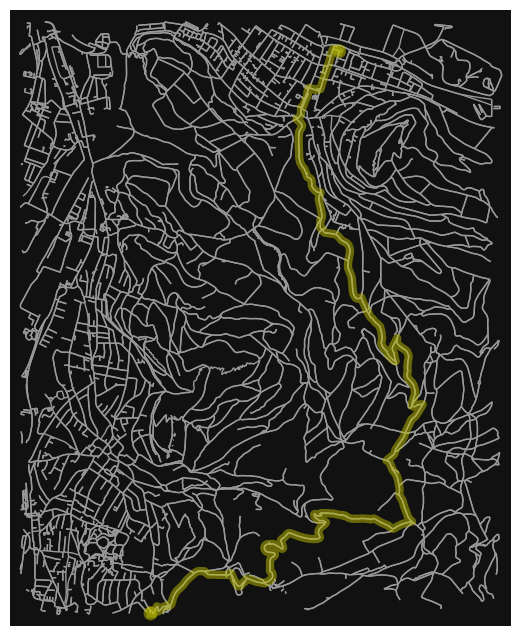

In [8]:
route = ox.routing._single_shortest_path(G, orig=start_point, dest=end_point, weight="forecast[{start_zeit}]")
fig, ax = ox.plot.plot_graph_route(G, route, route_color="y", route_linewidth=6, node_size=0)

In [43]:
print(route)

[423733899, 423733898, 280716373, 280716382, 280716380, 6389543291, 460211058, 2710701635, 2710701619, 276524809, 6122552450, 6109667096, 6109667100, 266388839, 289411716, 289411710, 1288235255, 6633787601, 3365768734, 1277957991, 288581266, 6634950426, 472328919, 294019200, 832527823, 294019204, 1276990837, 874369462, 874369249, 874369147, 7326566549, 266388684, 266388679, 262508276, 1275687572, 288279690, 262508266, 1275852871, 6204411504, 7174366949, 513422064, 6314726352, 304546991, 277025161, 360724307, 304546963, 277025167, 304545154, 304545166, 304545169, 7175441497, 599369731, 3263284551]


# 4.2 Routing (Custom)

In [ ]:
# TODO

# Exkurs Graph Projezieren

In [ ]:
# G = ox.projection.project_graph(G)
print(G.graph['crs'])